# 01 Generative Ai Applications

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply generative AI to images, text, or multimodal tasks
- Design and evaluate applications

## 🔗 Where this fits

**Builds on:** Course 10 — Units 1-3 (the model families you built) and Unit 4, which sets the boundaries any application has to respect.

**Used later in:** Course 12 (AIAT 126) — Unit 2, if your graduation project has a generative component.

---

## 🌍 Why this lesson exists — *Moffatt v. Air Canada*, 14 February 2024

Air Canada's website chatbot told Jake Moffatt he could book a full-fare ticket and apply the bereavement rate retroactively. No such policy existed. In *Moffatt v. Air Canada*, 2024 BCCRT 149, the British Columbia Civil Resolution Tribunal rejected the airline's argument that the chatbot was "a separate legal entity that is responsible for its own actions", found that Air Canada had not taken reasonable care to ensure the chatbot was accurate, and awarded **C$650.88** for negligent misrepresentation.

The sum is trivial; the holding is not. The generation stage of a pipeline is the company speaking, and the company owns what it says.

**What goes wrong without this:** pipelines are where generative AI actually ships, and the pipeline is where the checks live — or do not. A generate-only pipeline with no verification stage puts an unreviewed model output in front of a customer with your client's name on it.


## Where Generative AI Is Actually Used

By this point in the course you have built the core machinery yourself — GANs (Unit 1), language
models (Unit 2), VAEs and diffusion (Unit 3). This notebook connects that machinery to the
**application landscape**: what each model family powers in the real world, and how products chain
several models into one pipeline (which we then simulate hands-on).

### Text: Writing, Chat, and Knowledge Work

- **Assistants & chat** (ChatGPT, Claude, Gemini) — autoregressive next-token generation, the same mechanism as your Unit 2 char-LSTM at ~10⁶× scale
- **Marketing & copywriting** (Jasper, Copy.ai) — LLMs wrapped in templates, tone controls, and brand guidelines
- **Summarization & drafting** inside office suites (Microsoft Copilot, Google Workspace)

**Code is text too:** GitHub Copilot and Codex-style models autocomplete software the same way (notebook `06` of this unit is dedicated to them).

### Images and Video

- **Text-to-image** (Stable Diffusion, DALL-E, Midjourney) — diffusion models conditioned on text embeddings; you built the unconditional core of this in Unit 3
- **Design tooling** (Adobe Firefly, Canva) — generation embedded into editing workflows: fill, extend, restyle
- **Video generation** (Runway, Sora-class models) — diffusion extended with temporal consistency; currently the most compute-hungry frontier

Notebook `04` of this unit compares the big three image-model families in depth.

### Audio, Music, and Multimodality

- **Speech synthesis** (ElevenLabs, voice assistants) — neural TTS descended from WaveNet (notebook `05`)
- **Music generation** (Suno, Udio) — sequence models over musical tokens (notebook `03` builds one)
- **Multimodal models** (GPT-4V-class, Gemini) — one model consuming and producing several modalities; the research direction notebook `02` surveys

Other domains worth knowing: **medicine** (molecule generation for drug discovery), **education**
(personalized tutoring), **games** (asset and dialogue generation).

### The Pipeline Pattern

Real products rarely call one model once. The common shape is a **pipeline**:

> draft text → check quality/tone → derive prompts for other modalities → generate media → QA

The demo below **simulates** this pattern end-to-end with plain Python stand-ins (template
"LLM", word-list tone scorer, keyword prompt builder) so you can see the *architecture* without
any API keys or GPU downloads. Every stage prints what it produces — swap any stage for a real
model and the structure stays the same.

## 🌍 Real-World Application: Building a Multi-Modal Content Pipeline

Modern AI products combine multiple generative models in a single pipeline. Below is a working example of a content creation pipeline similar to what tools like Jasper, Copy.ai, and Adobe Firefly use internally.

=== Generative AI Content Pipeline Demo ===
Simulating the workflow used by Jasper, Copy.ai, Adobe Firefly


Pipeline Run 1:
  [Text] Generated: The future of intelligence is here. As seamless technologies emerge, transforms is key.
  [Tone] Positive (score=2)
  [Image Prompt] Professional photo of future, intelligence, seamless, 4K, ph...

Pipeline Run 2:
  [Text] Generated: Introducing our powerful new product that elevates your workflow with automation.
  [Tone] Positive (score=2)
  [Image Prompt] Professional photo of Introducing, powerful, product, 4K, ph...



Pipeline Run 3:
  [Text] Generated: The future of AI is here. As seamless technologies emerge, transforms is key.
  [Tone] Positive (score=2)
  [Image Prompt] Professional photo of future, seamless, technologies, 4K, ph...


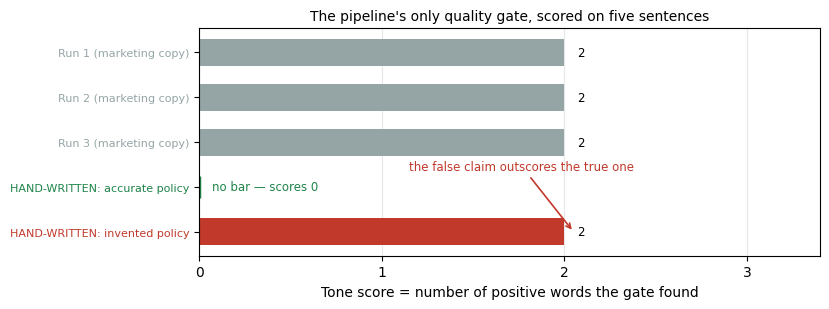


Tone score of the invented policy : 2
Tone score of the accurate policy : 0
A word-list gate ranks a cheerful falsehood ABOVE a correct sentence.

Pipeline complete.
Real products follow the same generate → check → derive-prompt shape,
with each simulated stage replaced by a real model (LLM, classifier, diffusion).


In [1]:
# Simulated multi-modal content pipeline: template "LLM" -> tone check -> image prompt.
# WHY: shows the pipeline architecture real products use, with each model swapped for a
# tiny plain-Python stand-in so it runs anywhere.
import time
import numpy as np
import matplotlib.pyplot as plt

# ── Simulate a multi-modal generative AI pipeline ─────────────────────────
# (uses only numpy/matplotlib — no heavy downloads needed)

print("=== Generative AI Content Pipeline Demo ===")
print("Simulating the workflow used by Jasper, Copy.ai, Adobe Firefly\n")

# Step 1: Text generation (simulated LLM output)
def simulate_llm(prompt, temperature=0.7):
    """Simulate LLM token-by-token generation."""
    templates = {
        "product": "Introducing our {adj} new product that {verb} your workflow with {noun}.",
        "blog":    "The future of {noun} is here. As {adj} technologies emerge, {verb} is key.",
        "ad":      "{verb} smarter, not harder. Our {adj} solution {noun} your business needs."
    }
    words = {'adj': ['powerful','innovative','seamless'], 'verb': ['transforms','elevates','revolutionizes'], 'noun': ['AI','automation','intelligence']}
    mode = np.random.choice(list(templates.keys()))
    text = templates[mode].format(**{k: np.random.choice(v) for k,v in words.items()})
    print("  [Text] Generated:", text)
    return text

# Step 2: Sentiment & tone analysis
def analyze_tone(text):
    positive_words = ['transforms', 'elevates', 'revolutionizes', 'powerful', 'innovative', 'seamless']
    score = sum(1 for w in text.lower().split() if w in positive_words)
    tone = "Positive" if score > 0 else "Neutral"
    print(f"  [Tone] {tone} (score={score})")
    return score

# Step 3: Image prompt generation (text→image bridge)
def analyze_tone_quiet(text):
    """Same rule as analyze_tone(), without printing — used by the figure below."""
    positive_words = ['transforms', 'elevates', 'revolutionizes', 'powerful', 'innovative', 'seamless']
    return sum(1 for w in text.lower().split() if w in positive_words)

def generate_image_prompt(text):
    keywords = [w for w in text.split() if len(w)>5][:3]
    prompt = f"Professional photo of {', '.join(keywords)}, 4K, photorealistic"
    print(f"  [Image Prompt] {prompt[:60]}...")
    return prompt

# Run the pipeline 3 times
results = []
for i in range(3):
    print(f"\nPipeline Run {i+1}:")
    text  = simulate_llm("create product ad")
    score = analyze_tone(text)
    img_prompt = generate_image_prompt(text)
    results.append({'text': text, 'score': score})
    time.sleep(0.1)

# ── Does the tone check actually gate anything? ──────────────────────────
# WHY: the pipeline's only quality stage is analyze_tone(). Score the three
# sentences the generator just produced, PLUS two sentences we write by hand:
# one cheerful invented refund policy (the Moffatt v. Air Canada failure), and
# one accurate, plainly-worded policy statement. Same scorer, all five.
probe_true  = ("Bereavement fares must be requested before travel; "
               "retroactive claims are not accepted.")
probe_false = ("Our seamless service transforms your booking — apply for the "
               "bereavement rate retroactively within 90 days of flying.")

labels  = [f"Run {i+1} (marketing copy)" for i in range(3)] + \
          ["HAND-WRITTEN: accurate policy", "HAND-WRITTEN: invented policy"]
texts   = [r['text'] for r in results] + [probe_true, probe_false]
tone    = [analyze_tone_quiet(t) for t in texts]
# grey = harmless copy, green = factually correct, red = a false claim
colours = ["#95a5a6"] * 3 + ["#1e8449", "#c0392b"]

fig, ax = plt.subplots(figsize=(8.4, 3.2))
bars = ax.barh(range(len(texts)), tone, color=colours, height=0.6)
ax.set_yticks(range(len(texts))); ax.set_yticklabels(labels, fontsize=8)
# a score of 0 draws no bar at all, so mark that row explicitly and colour the
# label text — otherwise the row silently disappears from the chart
for k, s in enumerate(tone):
    if s == 0:
        ax.plot([0], [k], marker="|", ms=16, mew=2.5, color=colours[k])
        ax.text(0.07, k, "no bar — scores 0", va="center", fontsize=8.5, color=colours[k])
for tick, col in zip(ax.get_yticklabels(), colours):
    tick.set_color(col)
ax.invert_yaxis()
ax.set_xlim(0, 3.4); ax.set_xticks([0, 1, 2, 3])
ax.set_xlabel("Tone score = number of positive words the gate found")
ax.set_title("The pipeline's only quality gate, scored on five sentences", fontsize=10)
for b, s in zip(bars, tone):
    if s > 0:
        ax.text(b.get_width() + 0.07, b.get_y() + b.get_height() / 2,
                f"{s}", va="center", fontsize=8.5)
ax.annotate("the false claim outscores the true one",
            xy=(tone[4] + 0.05, 4), xytext=(1.15, 2.62), fontsize=8.5, color="#c0392b",
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.2))
ax.grid(axis="x", alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

print("\nTone score of the invented policy :", tone[4])
print("Tone score of the accurate policy :", tone[3])
print("A word-list gate ranks a cheerful falsehood ABOVE a correct sentence.")
print("\nPipeline complete.")
print("Real products follow the same generate → check → derive-prompt shape,")
print("with each simulated stage replaced by a real model (LLM, classifier, diffusion).")

**Read the figure.** Five sentences, one scorer — the *only* quality stage this pipeline has.
The three grey bars are the marketing lines the generator just produced, each scoring **2**. The two
hand-written rows are the interesting ones. The row labelled in **green**, *accurate policy*, states
Air Canada's real bereavement rule correctly and scores **0** — it has no bar at all. The row
labelled in **red**, *invented policy*, makes up a retroactive refund in cheerful language and scores
**2**, tying the marketing copy and beating the true sentence, exactly as the red arrow says.
The gate is counting vocabulary, not checking facts, so it passes the falsehood and rates the
correct answer as the weakest output on the chart. That is the shape of the failure the tribunal
charged Air Canada for — and tuning the word list does not fix it, because the list has no way to
consult a policy.

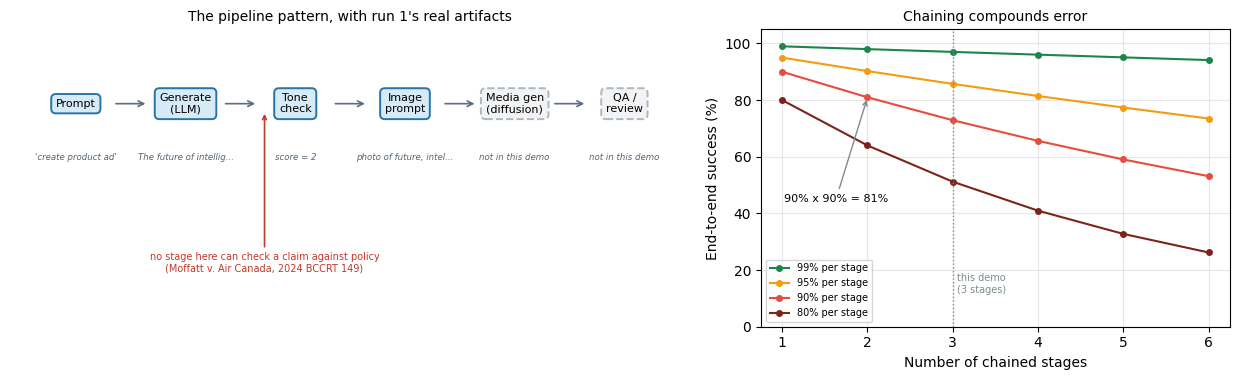

End-to-end success rate for a chain of N stages:
 N | 99%/stage | 95%/stage | 90%/stage | 80%/stage
 1 |      99.0% |      95.0% |      90.0% |      80.0%
 2 |      98.0% |      90.2% |      81.0% |      64.0%
 3 |      97.0% |      85.7% |      72.9% |      51.2%
 4 |      96.1% |      81.5% |      65.6% |      41.0%
 5 |      95.1% |      77.4% |      59.0% |      32.8%
 6 |      94.1% |      73.5% |      53.1% |      26.2%


In [2]:
# Draw the pipeline we just ran, and the arithmetic that decides how long a pipeline
# should be. WHY: the lesson makes two claims — "products chain models" and "chaining
# compounds error". Both are far easier to SEE than to read.
import numpy as np
import matplotlib.pyplot as plt

fig, (ax_pipe, ax_err) = plt.subplots(1, 2, figsize=(12.5, 3.9),
                                      gridspec_kw={"width_ratios": [1.45, 1]})

# ── LEFT: the pipeline shape, labelled with what run 1 ACTUALLY produced ──
run1 = results[0]
# same rule as generate_image_prompt() above, recomputed quietly for the label
kw = [w for w in run1["text"].split() if len(w) > 5][:3]
img_prompt = f"photo of {', '.join(kw)}"

stages = [
    ("Prompt",                "'create product ad'",          True),
    ("Generate\n(LLM)",       run1["text"][:22] + "...",      True),
    ("Tone\ncheck",           f"score = {run1['score']}",     True),
    ("Image\nprompt",         img_prompt[:22] + "...",        True),
    ("Media gen\n(diffusion)", "not in this demo",            False),
    ("QA /\nreview",          "not in this demo",             False),
]
ax_pipe.set_xlim(-0.6, len(stages) - 0.4); ax_pipe.set_ylim(-0.95, 1.05); ax_pipe.axis("off")
for k, (title, artifact, implemented) in enumerate(stages):
    face = "#d6eaf8" if implemented else "#f2f3f4"      # blue = built here, grey = named only
    edge = "#2874a6" if implemented else "#aeb6bf"
    ax_pipe.text(k, 0.55, title, ha="center", va="center", fontsize=8,
                 bbox=dict(boxstyle="round,pad=0.42", fc=face, ec=edge,
                           ls="solid" if implemented else "dashed", lw=1.4))
    ax_pipe.text(k, 0.22, artifact, ha="center", va="top", fontsize=6.2,
                 style="italic", color="#566573")
    if k < len(stages) - 1:                              # arrow to the next stage
        ax_pipe.annotate("", xy=(k + 0.66, 0.55), xytext=(k + 0.34, 0.55),
                         arrowprops=dict(arrowstyle="->", color="#5d6d7e", lw=1.2))
# the stage the Air Canada pipeline was missing
ax_pipe.annotate("no stage here can check a claim against policy\n(Moffatt v. Air Canada, 2024 BCCRT 149)",
                 xy=(1.72, 0.50), xytext=(1.72, -0.45), ha="center", va="top", fontsize=7, color="#c0392b",
                 arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.2))
ax_pipe.set_title("The pipeline pattern, with run 1's real artifacts", fontsize=10)

# ── RIGHT: end-to-end reliability = (per-stage rate) ** (number of stages) ──
n_stages = np.arange(1, 7)
for rate, colour in [(0.99, "#1e8449"), (0.95, "#f39c12"), (0.90, "#e74c3c"), (0.80, "#7b241c")]:
    ax_err.plot(n_stages, 100 * rate ** n_stages, "o-", color=colour, ms=4,
                label=f"{rate:.0%} per stage")
ax_err.annotate("90% x 90% = 81%", xy=(2, 81), xytext=(1.02, 44), fontsize=8,
                arrowprops=dict(arrowstyle="->", color="#7f8c8d", lw=1))
ax_err.axvline(3, ls=":", color="#7f8c8d", lw=1)
ax_err.text(3.05, 12, "this demo\n(3 stages)", fontsize=7, color="#7f8c8d")
ax_err.set_xlabel("Number of chained stages"); ax_err.set_ylabel("End-to-end success (%)")
ax_err.set_ylim(0, 105); ax_err.set_title("Chaining compounds error", fontsize=10)
ax_err.legend(fontsize=7, loc="lower left"); ax_err.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── The same numbers as a table, so the figure can be quoted ──────────────
print("End-to-end success rate for a chain of N stages:")
print(f"{'N':>2} | " + " | ".join(f"{r:.0%}/stage" for r in (0.99, 0.95, 0.90, 0.80)))
for n in n_stages:
    print(f"{n:>2} | " + " | ".join(f"{100 * r ** n:9.1f}%" for r in (0.99, 0.95, 0.90, 0.80)))


**Read the figure.**

*Left* — the six-stage shape the text described, with the artifacts **run 1 actually produced**
printed under each stage. Only the four blue stages exist in this notebook; the two dashed ones
are named in the text and not implemented. The red arrow points at stage 3, the only place in
this chain where a claim could have been checked against policy — and a word-list tone score is
not that check. That gap is the one the tribunal charged Air Canada for.

*Right* — why "add another model to the pipeline" is a decision, not a freebie. End-to-end
success is the per-stage rate raised to the number of stages, so two 90% stages give **81%** and
six give **53%**. The curves fall fastest exactly where products want to go: more stages, more
capability. A pipeline gets *less* reliable as it gets more ambitious, which is why the QA stage
on the right of the diagram is the one you cannot dash out.

## 💬 Discuss

1. Our pipeline is generate → tone-check → derive prompt. The tone check counts positive words. What would Air Canada's chatbot have needed at that stage instead — and is that a check a language model can perform on its own output?
2. Every stage here is a plain-Python stand-in. Which stage would you replace with a real model **last**, and why is that the interesting one to think about?
3. The tribunal held the company responsible for what its generator said. Where does that leave "the model made a mistake" as a defence for a consumer-facing deployment in Saudi Arabia? What would you put in the contract?


## ⚠️ Where this breaks

**A pipeline of stand-ins demonstrates architecture, not feasibility.** Nothing here tells you whether a real LLM stage would meet a latency, cost or accuracy budget — and those three are what actually kill pipelines in production.

**Chaining generators compounds error.** Each stage's output is the next stage's input, so a 90%-correct stage feeding another 90%-correct stage yields 81% end to end. Product quality falls faster than component quality suggests, and the failures are correlated in ways component testing does not reveal.

**A word-list tone score is not a quality gate.** It cannot detect a fluent false claim, which is precisely the failure that reached the tribunal. A check that only measures sentiment will pass a confident, cheerful, invented refund policy.

**Cheaper alternative for most business writing:** templates with slots. They cannot hallucinate a policy, they are auditable line by line, and for the marketing copy in this demo they are frequently the correct engineering answer. Reach for generation when the output space is genuinely open.


## 📝 Summary

In this notebook, you:

- Mapped the **application landscape** of generative AI — text/chat, code, images and video,
  audio/music, and multimodal products — onto the model families you built in Units 1–3
- Saw the **pipeline pattern** behind real products: generate → quality-check → derive prompts
  for other modalities
- Ran a **simulated** multi-modal content pipeline (template "LLM" → tone scorer → image-prompt
  builder), then showed that its word-list tone gate scores an invented refund policy **above** a
  correct one — a quality stage that cannot check a claim

**Honest scope note:** every model in the demo is a plain-Python stand-in — the point is the
pipeline *architecture*, not model quality.

**Next steps:** the rest of this unit goes deeper on each modality (music `03`, advanced image
models `04`, audio `05`, code `06`) — then build your own generator in the unit exercise.

## 📚 References & Further Reading

**Foundational Papers:**
- Goodfellow et al. (2014) — [Generative Adversarial Nets](https://arxiv.org/abs/1406.2661) *(the adversarial recipe behind Unit 1)*
- Vaswani et al. (2017) — [Attention Is All You Need](https://arxiv.org/abs/1706.03762) *(the Transformer behind every text and code assistant in this map)*
- Rombach et al. (2022) — [High-Resolution Image Synthesis with Latent Diffusion Models](https://arxiv.org/abs/2112.10752) *(Stable Diffusion — the open text-to-image workhorse)*

**Recent:**
- Bommasani et al. (2021) — [On the Opportunities and Risks of Foundation Models](https://arxiv.org/abs/2108.07258) *(the report that framed today's application landscape)*